# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective


Sampling follows annealed MCMC

Input:
- Transition kernels $k_t(· | ·)$
- Initial distribution $p_T(·)$
- Number of steps $N$

Sampling steps:
- Initialize $x_T \sim p_T(·)$
- for $t = T, T-1, ... ,  0$ do
    - for $i = 1, ... ,  N$ do
        - $x_t \sim k_t(· | x_t)$
    - end for
    - $x_{t-1} = x_t$
- end for

For our transition kernel, we choose ULA algorithm
$$q(x_t\mid x_{t-1}) = N(x_{t-1} + \frac{\sigma_L^2}{2} \nabla_x f(x_{t-1}), \sigma_L^2 I)$$
We choose step size $\beta_t$
$$x_{t+1} = x_t - \beta_t \nabla_x p_t(x) + \sqrt{2} \beta_t z$$
where
$$\nabla \text{model output} = \nabla_x p_t(x) = \frac{\epsilon_{\theta}(x_t, t)}{\sqrt{1-\bar{\alpha}_t}}$$
See appendix b.2 of reduce reuse recycle and section 2.2

### Setup

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- hyperparams ----
mu_0, sigma_0 = 0.0, 1.0
n_diffusion_steps = 100

n_steps = 15_000
batch_size = 128
lr = 3e-4

train_dataset_size = 50_000
n_samples = 50_000

n_langevin_steps = 5

ckpt_dir = "model_checkpoints"

### Schedule

In [2]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps, dtype=torch.float32) / timesteps
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

betas = cosine_beta_schedule(n_diffusion_steps).to(device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)  # alphā_t
# sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

ts_desc = torch.arange(n_diffusion_steps - 1, -1, -1, device=device)

### Model

In [3]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        if t.dim() == 2:
            t = t.squeeze(-1)

        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class MLP(nn.Module):
    def __init__(
        self,
        x_dim=1,
        hidden_dim=128,
        time_dim=32,
        n_layers=4,
    ):
        super().__init__()

        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.input = nn.Linear(x_dim + time_dim, hidden_dim)

        self.layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )

        self.output = nn.Linear(hidden_dim, x_dim)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        h = torch.cat([x, t_emb], dim=-1)

        h = self.input(h)
        h = F.silu(h)

        for layer in self.layers:
            h = h + F.silu(layer(h))

        return self.output(h)


### Train Model

In [4]:
def train_model(temp, save_path, log_every=1000):
    # training data: N(mu0, sigma0/sqrt(temp))  (keep on CPU; move batches to GPU)
    x0_all = torch.normal(
        mean=mu_0,
        std=sigma_0 / np.sqrt(temp),
        size=(train_dataset_size, 1),
    )
    loader = DataLoader(
        TensorDataset(x0_all),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=0,      # keep simple; set >0 if you want
        pin_memory=True,    # helps H2D transfer
    )

    model = MLP().to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    model.train()

    data_iter = iter(loader)

    for step in range(1, n_steps + 1):
        # get a batch (restart dataloader when exhausted; still no "epochs" variable)
        try:
            (x0,) = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)  # reshuffles because shuffle=True
            (x0,) = next(data_iter)

        x0 = x0.to(device, non_blocking=True)

        t = torch.randint(0, n_diffusion_steps, (batch_size, 1), device=device)
        a_bar = alpha_bar[t]
        
        noise = torch.randn_like(x0)
        xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

        eps_hat = model(xt, t)
        loss = ((noise - eps_hat) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % log_every == 0:
            print(f"temp={temp} step={step} loss={loss.item():.4f}")

    torch.save(model.state_dict(), save_path)
    return model

### Sampling

In [5]:
@torch.no_grad()
def compute_tsr(t_batch, T_modeling, T_sampling):
    sigma = sigma_0 / np.sqrt(T_modeling)

    a_bar = alpha_bar[t_batch[0,0].long().item()]
    sigma_t = torch.sqrt(1.0 - a_bar)
    alpha_t = torch.sqrt(a_bar)

    eta_t = (alpha_t**2) / (sigma_t**2)
    num = eta_t * (sigma ** 2) + 1
    den = (eta_t * (sigma ** 2)) / T_sampling + 1
    return num / den

In [6]:
@torch.no_grad()
def r_curve_func(x, x_hat, s):
    return x + s * (x_hat - x)

@torch.no_grad()
def r_deriv_func(x, x_hat, s):
    ones = torch.ones_like(s)
    return ones * (x_hat - x)

@torch.no_grad()
def compute_log_transition_ratio(x, x_hat, t_batch, model, step):
    """Compute log of transition ratio - more stable"""
    score_x =  compute_score(model, x, t_batch)
    score_x_hat =  compute_score(model, x_hat, t_batch)

    # Forward
    forward_diff = x_hat - x - step * score_x
    forward_sq = (forward_diff**2).sum(dim=-1, keepdim=True)
    
    # Backward
    backward_diff = x - x_hat - step * score_x_hat
    backward_sq = (backward_diff**2).sum(dim=-1, keepdim=True)
    
    # Return log ratio instead of ratio
    return (forward_sq - backward_sq) / (4 * step)

@torch.no_grad()
def compute_score(model, x, t_batch):
    eps_hat = model(x, t_batch)
    a_bar = alpha_bar[t_batch[0, 0].long().item()]
    return - eps_hat / torch.sqrt(1.0 - a_bar)

@torch.no_grad()
def compute_score_integral(x, x_hat, t_batch, model, n_segments):
    s = torch.linspace(0.0, 1.0, n_segments, device=device)
    
    # Path and derivative: (n_samples, n_segments)
    r = r_curve_func(x, x_hat, s)
    r_deriv = r_deriv_func(x, x_hat, s)
    n_samples = r.shape[0]
    
    # Evaluate score along path
    r_flat = r.reshape(-1, 1)
    t_flat = t_batch[0].item() * torch.ones_like(r_flat)
    epsilon = model(r_flat, t_flat).reshape(n_samples, -1)
    
    # Integrate: (n_samples, n_segments) -> (n_samples,)
    integrand = epsilon * r_deriv
    f = -torch.trapz(integrand, s, dim=1).unsqueeze(-1) 
    
    return f  # (n_samples, 1)

@torch.no_grad()
def compute_correction(x, x_hat, t_batch, model, step, num_segments = 10):

    f = compute_score_integral(x, x_hat, t_batch, model, num_segments)
    
    log_transition_ratio = compute_log_transition_ratio(x, x_hat, t_batch, model, step)

    t = t_batch[0].item()
    sigma_t = torch.sqrt(1 - alpha_bar[t])
    
    a = torch.clamp(torch.exp(f / sigma_t + log_transition_ratio), max=1.0)

    print(a.mean().item())

    u = torch.rand(n_samples, 1, device=device)
    
    accept_mask = ( u < a )  

    x = torch.where(accept_mask, x_hat, x)
    
    return x

In [7]:
@torch.no_grad()
def langevin_sampling(model, T_modeling, T_sampling, method = "ULA", step_scale=1.0, n_samples=n_samples):
    model.eval()
    x = torch.randn(n_samples, 1, device=device)
    ones = torch.ones(n_samples, 1, device=device)

    for t in ts_desc:
        t_batch = (t * ones).long()

        for _ in range(n_langevin_steps):
            step = betas[t] * step_scale

            score_hat = compute_score(model, x, t_batch)

            tsr = compute_tsr(t_batch, T_modeling, T_sampling)
            noise = torch.randn_like(x)

            x_hat = x + step * score_hat * tsr + noise * torch.sqrt(2.0 * step)

            if method == "MALA":
                x = compute_correction(x, x_hat, t_batch, model, step)

            elif method == "ULA":
                x = x_hat
    return x

### Compare and Plot

In [8]:
def load_model(path):
    m = MLP().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

def compare(temp_target, method, step_scale):
    # model trained at temp_target (your "true")
    m_true = load_model(f"{ckpt_dir}/model_T{temp_target:.1f}.pt")
    x_true = langevin_sampling(m_true, T_modeling=temp_target, T_sampling=1.0, method=method, step_scale=step_scale)

    # model trained at temp=1 but sampled at temp_target (your "approx")
    m_base = load_model(f"{ckpt_dir}/model_T{1.0:.1f}.pt")
    x_base = langevin_sampling(m_base, T_modeling=1.0, T_sampling=temp_target, method=method, step_scale=step_scale)

    # plot vs analytic gaussian
    xlim = 4
    x_axis = np.linspace(-xlim, xlim, 500)
    std = sigma_0 / np.sqrt(temp_target)
    pdf = (1.0 / (np.sqrt(2*np.pi) * std)) * np.exp(-0.5 * ((x_axis - mu_0)/std)**2)

    bins = np.linspace(-xlim, xlim, 100)
    plt.figure(figsize=(5,4))
    _ = plt.hist(x_base.cpu().numpy(), bins=bins, density=True, alpha=0.5, label="samples (model T=1)")
    _ = plt.hist(x_true.cpu().numpy(), bins=bins, density=True, alpha=0.5, label=f"samples (model T={temp_target})")
    plt.plot(x_axis, pdf, label="true gaussian pdf")
    plt.title(f"{method} sample distribution at T={temp_target}")
    plt.xlim(-xlim, xlim)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return x_true, x_base

### Implementation

0.7915248870849609
0.7936331629753113
0.7960994839668274
0.7942468523979187
0.7946441769599915
0.8621635437011719
0.862845778465271
0.862109363079071
0.8622026443481445
0.8619509339332581
0.9100627899169922
0.9106969833374023
0.9114478826522827
0.9103801250457764
0.9097185730934143
0.9382947683334351
0.9378418326377869
0.9371526837348938
0.9380665421485901
0.9378013610839844
0.9532077312469482
0.9533082842826843
0.9539806246757507
0.953190267086029
0.9541224837303162
0.9636738896369934
0.9633423089981079
0.9637917876243591
0.963262140750885
0.9633938670158386
0.9704553484916687
0.9707902669906616
0.9703781604766846
0.9704588055610657
0.9706400036811829
0.9755469560623169
0.9755098819732666
0.9762254357337952
0.9755280017852783
0.9759945869445801
0.9796319007873535
0.9795107841491699
0.9797484278678894
0.9794133305549622
0.9796494841575623
0.9824531078338623
0.9822542071342468
0.9821763038635254
0.9823390245437622
0.9822165369987488
0.98450767993927
0.9845315217971802
0.9843924641609192

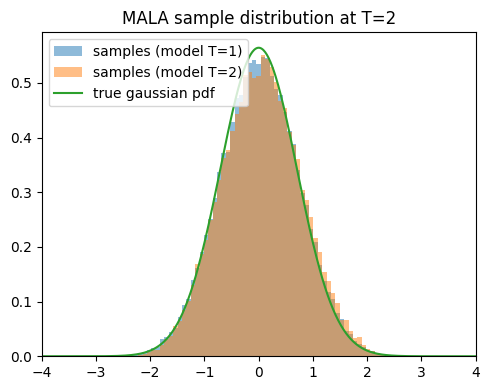

In [9]:
temperature = 2

# save_path = f"{ckpt_dir}/model_T{temperature:.1f}.pt"
# train_model(temperature, save_path)
_ = compare(temperature, "MALA", step_scale = 1)